# 🚗 Auto Auction Labor Forecasting
## Portfolio Analysis Notebook

**Author:** Demarr Rice  
**Stack:** Python · SQL · SQLite · Claude API  
**Dataset:** 1 year of simulated auto auction operations (2024)

---

This notebook walks through the full labor forecasting pipeline:
1. Data overview & validation
2. Volume patterns by day-of-week and season
3. SQL-driven staffing forecasts
4. Variance analysis (planned vs. actual)
5. AI-generated supervisor briefings

---


In [3]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from forecast.forecast_engine import (
    get_week_forecast, get_wow_variance,
    get_monthly_trend, get_anomalies,
    build_forecast_context, forecast_staff_for_volume,
)
from forecast.ai_summary import generate_summary
from datetime import date

# Optional: set your API key here or via environment variable
# import os; os.environ['ANTHROPIC_API_KEY'] = 'sk-ant-...'

DB_PATH = os.path.abspath('../auction_data.db')
print('DB path:', DB_PATH)
print('Exists:', os.path.exists(DB_PATH))


DB path: c:\Users\deric\OneDrive\Documents\auction-labor-forecast\auction_data.db
Exists: True


## 1. Data Overview

First let's verify the database loaded correctly and understand the shape of our data.

In [4]:
conn = sqlite3.connect(DB_PATH)
df = pd.read_sql_query("SELECT * FROM daily_operations", conn)
conn.close()

print(f"Rows: {len(df)}")
print(f"Date range: {df['date'].min()} → {df['date'].max()}")
df.head(10)


Rows: 314
Date range: 2024-01-01 → 2024-12-31


,id,date,day_of_week,month,is_sale_day,planned_volume,actual_volume,staff_check_in,staff_detailing,staff_transport,staff_title_admin,staff_lane_support,total_planned_staff,total_actual_staff,variance_staff
0,1,2024-01-01,Monday,1,0,163,159,2,15,4,2,0,23,20,-3
1,2,2024-01-02,Tuesday,1,1,161,163,2,15,4,2,3,26,26,0
2,3,2024-01-03,Wednesday,1,1,204,202,3,19,5,2,4,33,30,-3
3,4,2024-01-04,Thursday,1,0,159,159,2,14,3,1,0,20,18,-2
4,5,2024-01-05,Friday,1,0,146,148,2,13,3,1,0,19,17,-2
5,6,2024-01-06,Saturday,1,0,87,87,1,8,2,1,0,12,11,-1
6,7,2024-01-08,Monday,1,0,170,175,2,15,4,2,0,23,20,-3
7,8,2024-01-09,Tuesday,1,1,181,174,3,16,4,2,3,28,26,-2
8,9,2024-01-10,Wednesday,1,1,207,198,3,19,5,2,4,33,31,-2
9,10,2024-01-11,Thursday,1,0,162,163,2,15,4,2,0,23,23,0


In [ ]:
df.describe()




## 2. Volume Patterns

### What does a typical week look like?
Let's look at average daily volume by day of week to understand demand patterns.

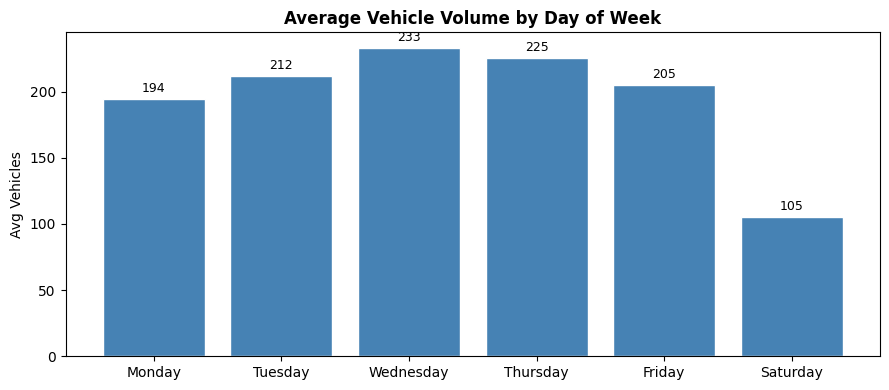

In [5]:
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday']
dow_avg = (df.groupby('day_of_week')['actual_volume']
             .mean()
             .reindex(dow_order))

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(dow_avg.index, dow_avg.values, color='steelblue', edgecolor='white')
ax.bar_label(bars, fmt='%.0f', padding=3, fontsize=9)
ax.set_title('Average Vehicle Volume by Day of Week', fontweight='bold')
ax.set_ylabel('Avg Vehicles')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()


Wednesday peaks at 233 vehicles on average, the highest of the week driven by primary sale day activity. Thursday follows closely at 225. Saturday drops to just 105 vehicles, less than half of Wednesday, meaning the facility can operate with a significantly smaller crew on weekends.

### How does volume change throughout the year?
Let's look at monthly patterns to understand seasonal demand.

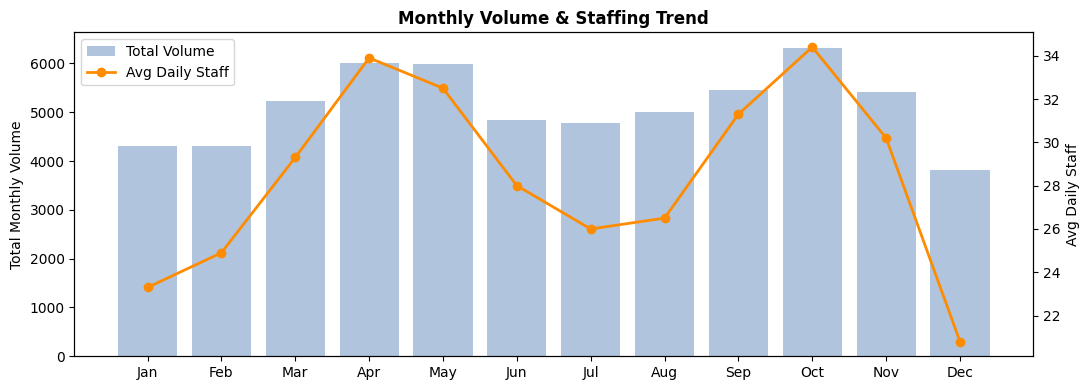

In [6]:
monthly = get_monthly_trend()

fig, ax1 = plt.subplots(figsize=(11, 4))
ax2 = ax1.twinx()

ax1.bar(monthly['month_name'], monthly['total_volume'],
        color='lightsteelblue', label='Total Volume')
ax2.plot(monthly['month_name'], monthly['avg_daily_staff'],
         color='darkorange', marker='o', linewidth=2, label='Avg Daily Staff')

ax1.set_ylabel('Total Monthly Volume')
ax2.set_ylabel('Avg Daily Staff')
ax1.set_title('Monthly Volume & Staffing Trend', fontweight='bold')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.show()


This chart shows that April and October will be our busiest months with about 6000 cars in those months. December will be our slowest month due to the holidays so we should reduce hours in December but hire more in April and October.

## 3. SQL-Driven Staffing Forecast

Using labor standards (minutes per vehicle per role), we can calculate exact headcount needed for any given volume. Below is the 7-day forecast for the week of April 1, 2024.

In [7]:
forecast_date = date(2024, 4, 1)   # Change this to any Monday in 2024
week = get_week_forecast(forecast_date)

display_cols = ['date','day_of_week','is_sale_day','planned_volume',
                'staff_check_in','staff_detailing','staff_transport',
                'staff_title_admin','staff_lane_support','total_planned_staff']
week[display_cols].style.background_gradient(subset=['total_planned_staff'], cmap='Blues')


,date,day_of_week,is_sale_day,planned_volume,staff_check_in,staff_detailing,staff_transport,staff_title_admin,staff_lane_support,total_planned_staff
0,2024-04-01,Monday,0,213,3,19,5,2,0,29
1,2024-04-02,Tuesday,1,233,3,21,5,2,4,35
2,2024-04-03,Wednesday,1,263,4,24,6,3,5,42
3,2024-04-04,Thursday,0,285,4,26,7,3,0,40
4,2024-04-05,Friday,0,223,3,20,5,2,0,30
5,2024-04-06,Saturday,0,118,1,11,2,1,0,15


As you see from this chart we will need the most staff on Wednesday due to the high planned volume of 263 vehicles. There's no lane support on Monday due to it notbeing a sale day. As you can see detailing takes the most time so we need to staff accordingly.

### What-If: Custom Volume Input

In [ ]:
custom_volume = 250   # ← change this
is_sale = True        # ← change this

breakdown = forecast_staff_for_volume(custom_volume, is_sale)
print(f"For {custom_volume} vehicles on a {'sale' if is_sale else 'non-sale'} day:")
for role, count in breakdown.items():
    label = role.replace('_',' ').title()
    print(f"  {label:<18} {count} staff")


## 4. Variance Analysis (Planned vs. Actual)

Variance measures how often actual staffing differed from the plan. 
Negative variance means we were understaffed. Positive means overstaffed.

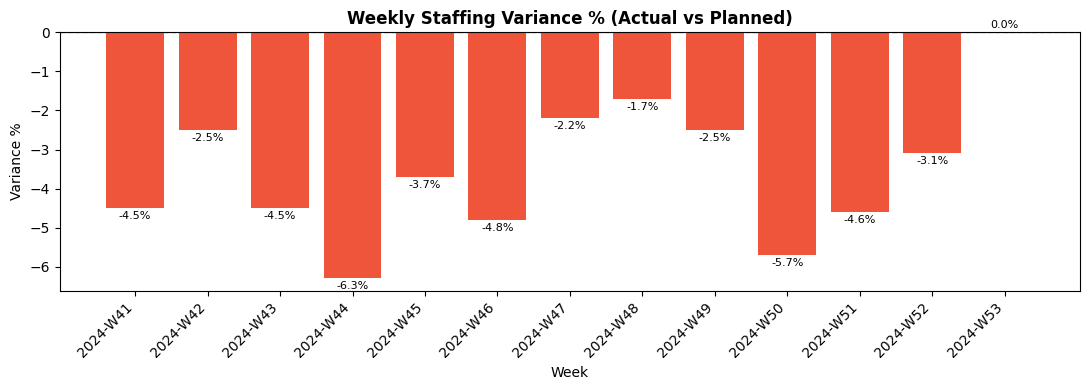

In [8]:
wow = get_wow_variance(date(2024, 12, 31), weeks=12)

colors = ['#ef553b' if v < 0 else '#00cc96' for v in wow['variance_pct']]
fig, ax = plt.subplots(figsize=(11, 4))
bars = ax.bar(wow['week'], wow['variance_pct'], color=colors)
ax.axhline(0, color='gray', linestyle='--', linewidth=1)
ax.bar_label(bars, fmt='%.1f%%', padding=2, fontsize=8)
ax.set_title('Weekly Staffing Variance % (Actual vs Planned)', fontweight='bold')
ax.set_ylabel('Variance %')
ax.set_xlabel('Week')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


This chart shows the variance percentage of our staffing, being negative meaning we were understaffed that week. It looks like week 44 was our worst week with a -6.3% variance and we were understaffed and we should do more planning like hiring my temps or adjusting our model to fix it.

### Anomaly Log — High-Variance Days

In [ ]:
anomalies = get_anomalies(threshold_pct=15)
anomalies.style.applymap(
    lambda v: 'color: red' if v == 'Understaffed' else 'color: green',
    subset=['status']
)


## 5. AI-Generated Supervisor Briefing

The Claude API converts structured forecast data into a plain-English 
briefing a floor supervisor can read in 30 seconds before a shift.

In [9]:
ctx = build_forecast_context(date(2024, 4, 2))   # Tuesday = sale day

import json
print("=== Forecast Context Passed to Claude ===")
print(json.dumps(ctx, indent=2))


=== Forecast Context Passed to Claude ===
{
  "date": "2024-04-02",
  "day_of_week": "Tuesday",
  "is_sale_day": true,
  "planned_volume": 233,
  "actual_volume": 235,
  "staff_breakdown": {
    "check_in": 3,
    "detailing": 21,
    "transport": 5,
    "title_admin": 2,
    "lane_support": 4
  },
  "total_planned_staff": 35,
  "total_actual_staff": 34,
  "variance_staff": -1,
  "recent_avg_variance_pct": -4.0,
  "anomaly_days_last_month": 4
}


In [ ]:
# Requires your API key
import os
os.environ['ANTHROPIC_API_KEY'] = 'your-key-here'

summary = generate_summary(ctx)
print("=== AI Supervisor Briefing ===")
print(summary)


=== AI Supervisor Briefing ===
Today requires 35 total staff but only 34 showed up, leaving us one person short on this Tuesday sale day with 235 cars going through the lanes. The good news is we're actually running two cars over our planned volume of 233, indicating strong business flow. With detailing needing 21 people as our largest crew, that's likely where we'll feel the shortage most. This is the fourth high-variance day this month, following our recent trend of running about 4% under planned staffing levels. Consider pulling one person from transport or title/admin to help detailing if the car flow starts backing up.


---
## Summary

This project demonstrates:

| Skill | Implementation |
|---|---|
| **SQL** | SQLite queries for staffing forecasts, variance analysis, UPLH |
| **Python / pandas** | Data generation, transformation, forecast engine |
| **AI Integration** | Claude API for natural language summaries |
| **Data Visualization** | matplotlib charts for operational patterns |
| **Business Logic** | Labor standards, ceiling staffing calculations, anomaly detection |

The same pipeline powers an interactive Streamlit dashboard — run `streamlit run app/streamlit_app.py` to see it live.
